<a href="https://colab.research.google.com/github/sainathnallagonda/Jamboree-Education---Linear-Regression/blob/main/Jamboree_Education_Linear_Regression(sainath).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Context**

Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

Importing all the necessary Libraries

In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.stats.api as sms
import warnings
warnings.filterwarnings("ignore")

In [169]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv
To: /content/Jamboree_Admission.csv
100% 16.2k/16.2k [00:00<00:00, 39.5MB/s]


In [170]:
df = pd.read_csv('Jamboree_Admission.csv')

In [171]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [173]:
df.drop(columns="Serial No.",inplace=True)

Removing serial No. column which is unneceseray

In [174]:
df.isnull().sum()


,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


There are no null values

In [175]:
df.shape

(500, 8)

In [176]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [177]:
df.duplicated().sum()

np.int64(0)

In [178]:
df = df.drop_duplicates()

In [179]:
df.rename(columns={'LOR ':'LOR', 'Chance of Admit ':'Chance of Admit'}, inplace=True)


**Univariate Analysis**

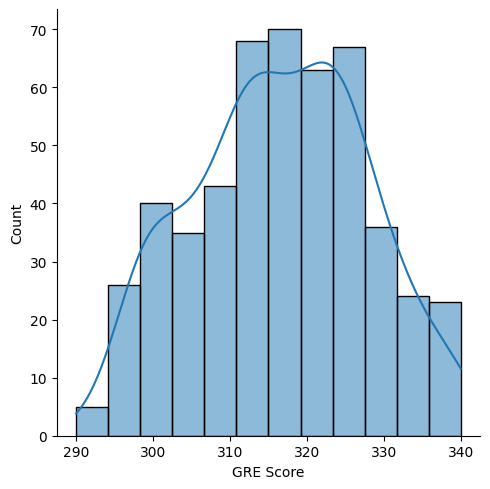

In [180]:
sns.displot(df['GRE Score'],kde=True)


<Axes: xlabel='TOEFL Score', ylabel='Count'>

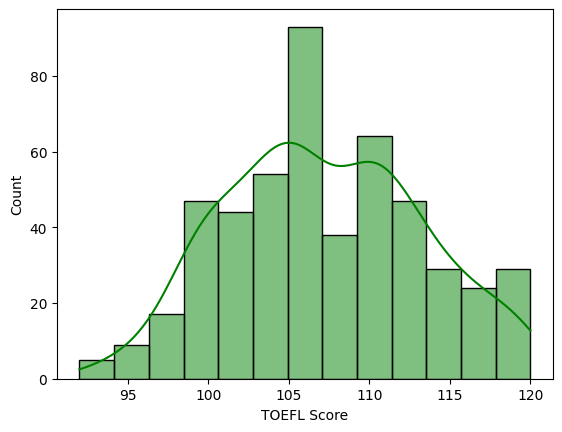

In [181]:
sns.histplot(df['TOEFL Score'],color='green',kde=True)





**Bivariate Analysis**

<Axes: xlabel='University Rating', ylabel='Chance of Admit'>

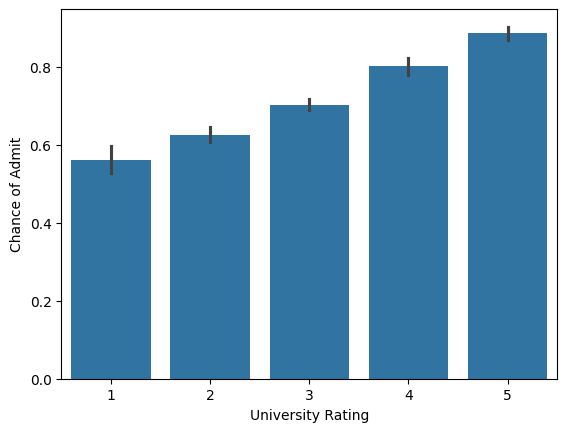

In [182]:
sns.barplot(x=df['University Rating'],y=df['Chance of Admit'])


In [183]:
df_1 = df[['SOP','LOR','Chance of Admit']]

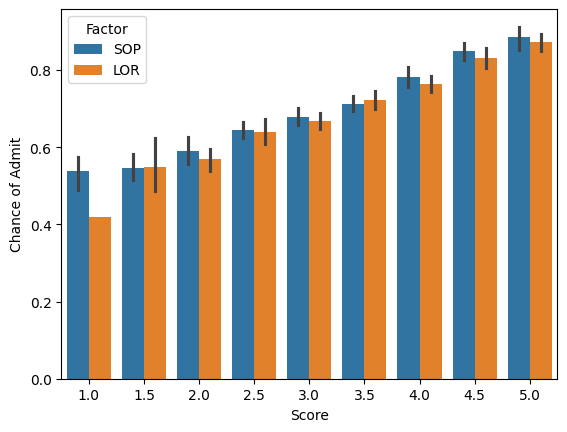

In [184]:

df_melted = df_1.melt(id_vars='Chance of Admit', value_vars=['SOP', 'LOR'], var_name='Factor', value_name='Score')
sns.barplot(x='Score', y='Chance of Admit', hue='Factor', data=df_melted)
plt.show()


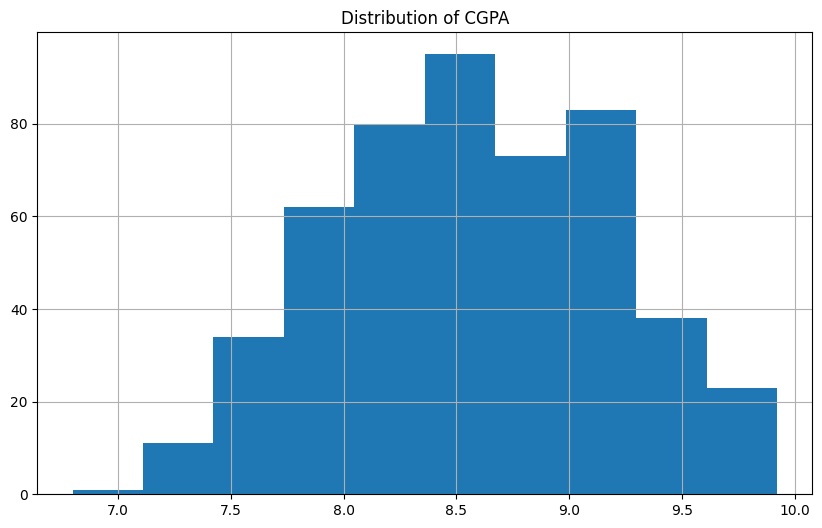

In [185]:
df['CGPA'].hist(bins=10, figsize=(10, 6))
plt.title('Distribution of CGPA')
plt.show()

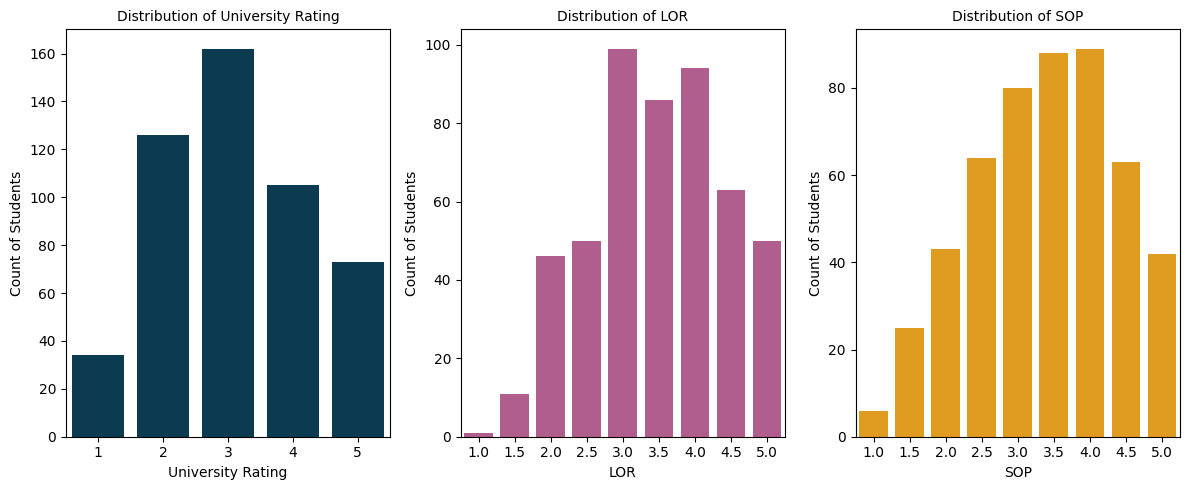

In [186]:
plt.figure(figsize=(12,5))
i=1
colors = ['#003f5c','#bc5090','#ffa600']

for col in ('University Rating','LOR','SOP'):
  ax = plt.subplot(1,3,i)
  sns.countplot(x=df[col],color=colors[i-1])
  plt.title(f'Distribution of {col}', fontsize=10)
  plt.xlabel(col)
  plt.ylabel('Count of Students')
  i+=1

plt.tight_layout()
plt.show();

It can be observed that the most frequent value of categorical features is
University Rating: 3,LOR: 3,SOP: 4



<Axes: xlabel='Research', ylabel='count'>

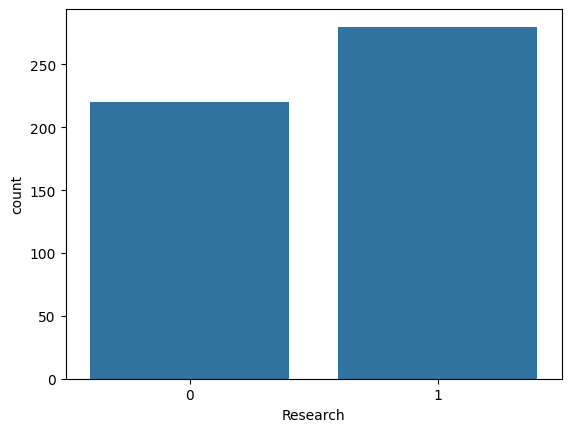

In [187]:
sns.countplot(x=df['Research'])


<Axes: >

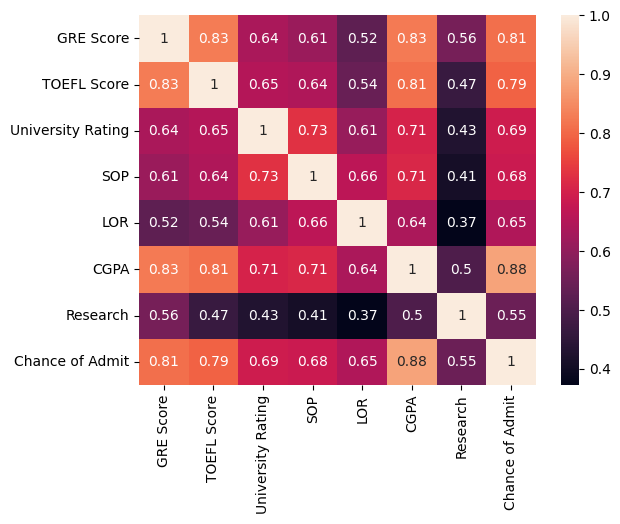

In [188]:
sns.heatmap(df.corr(),annot=True)


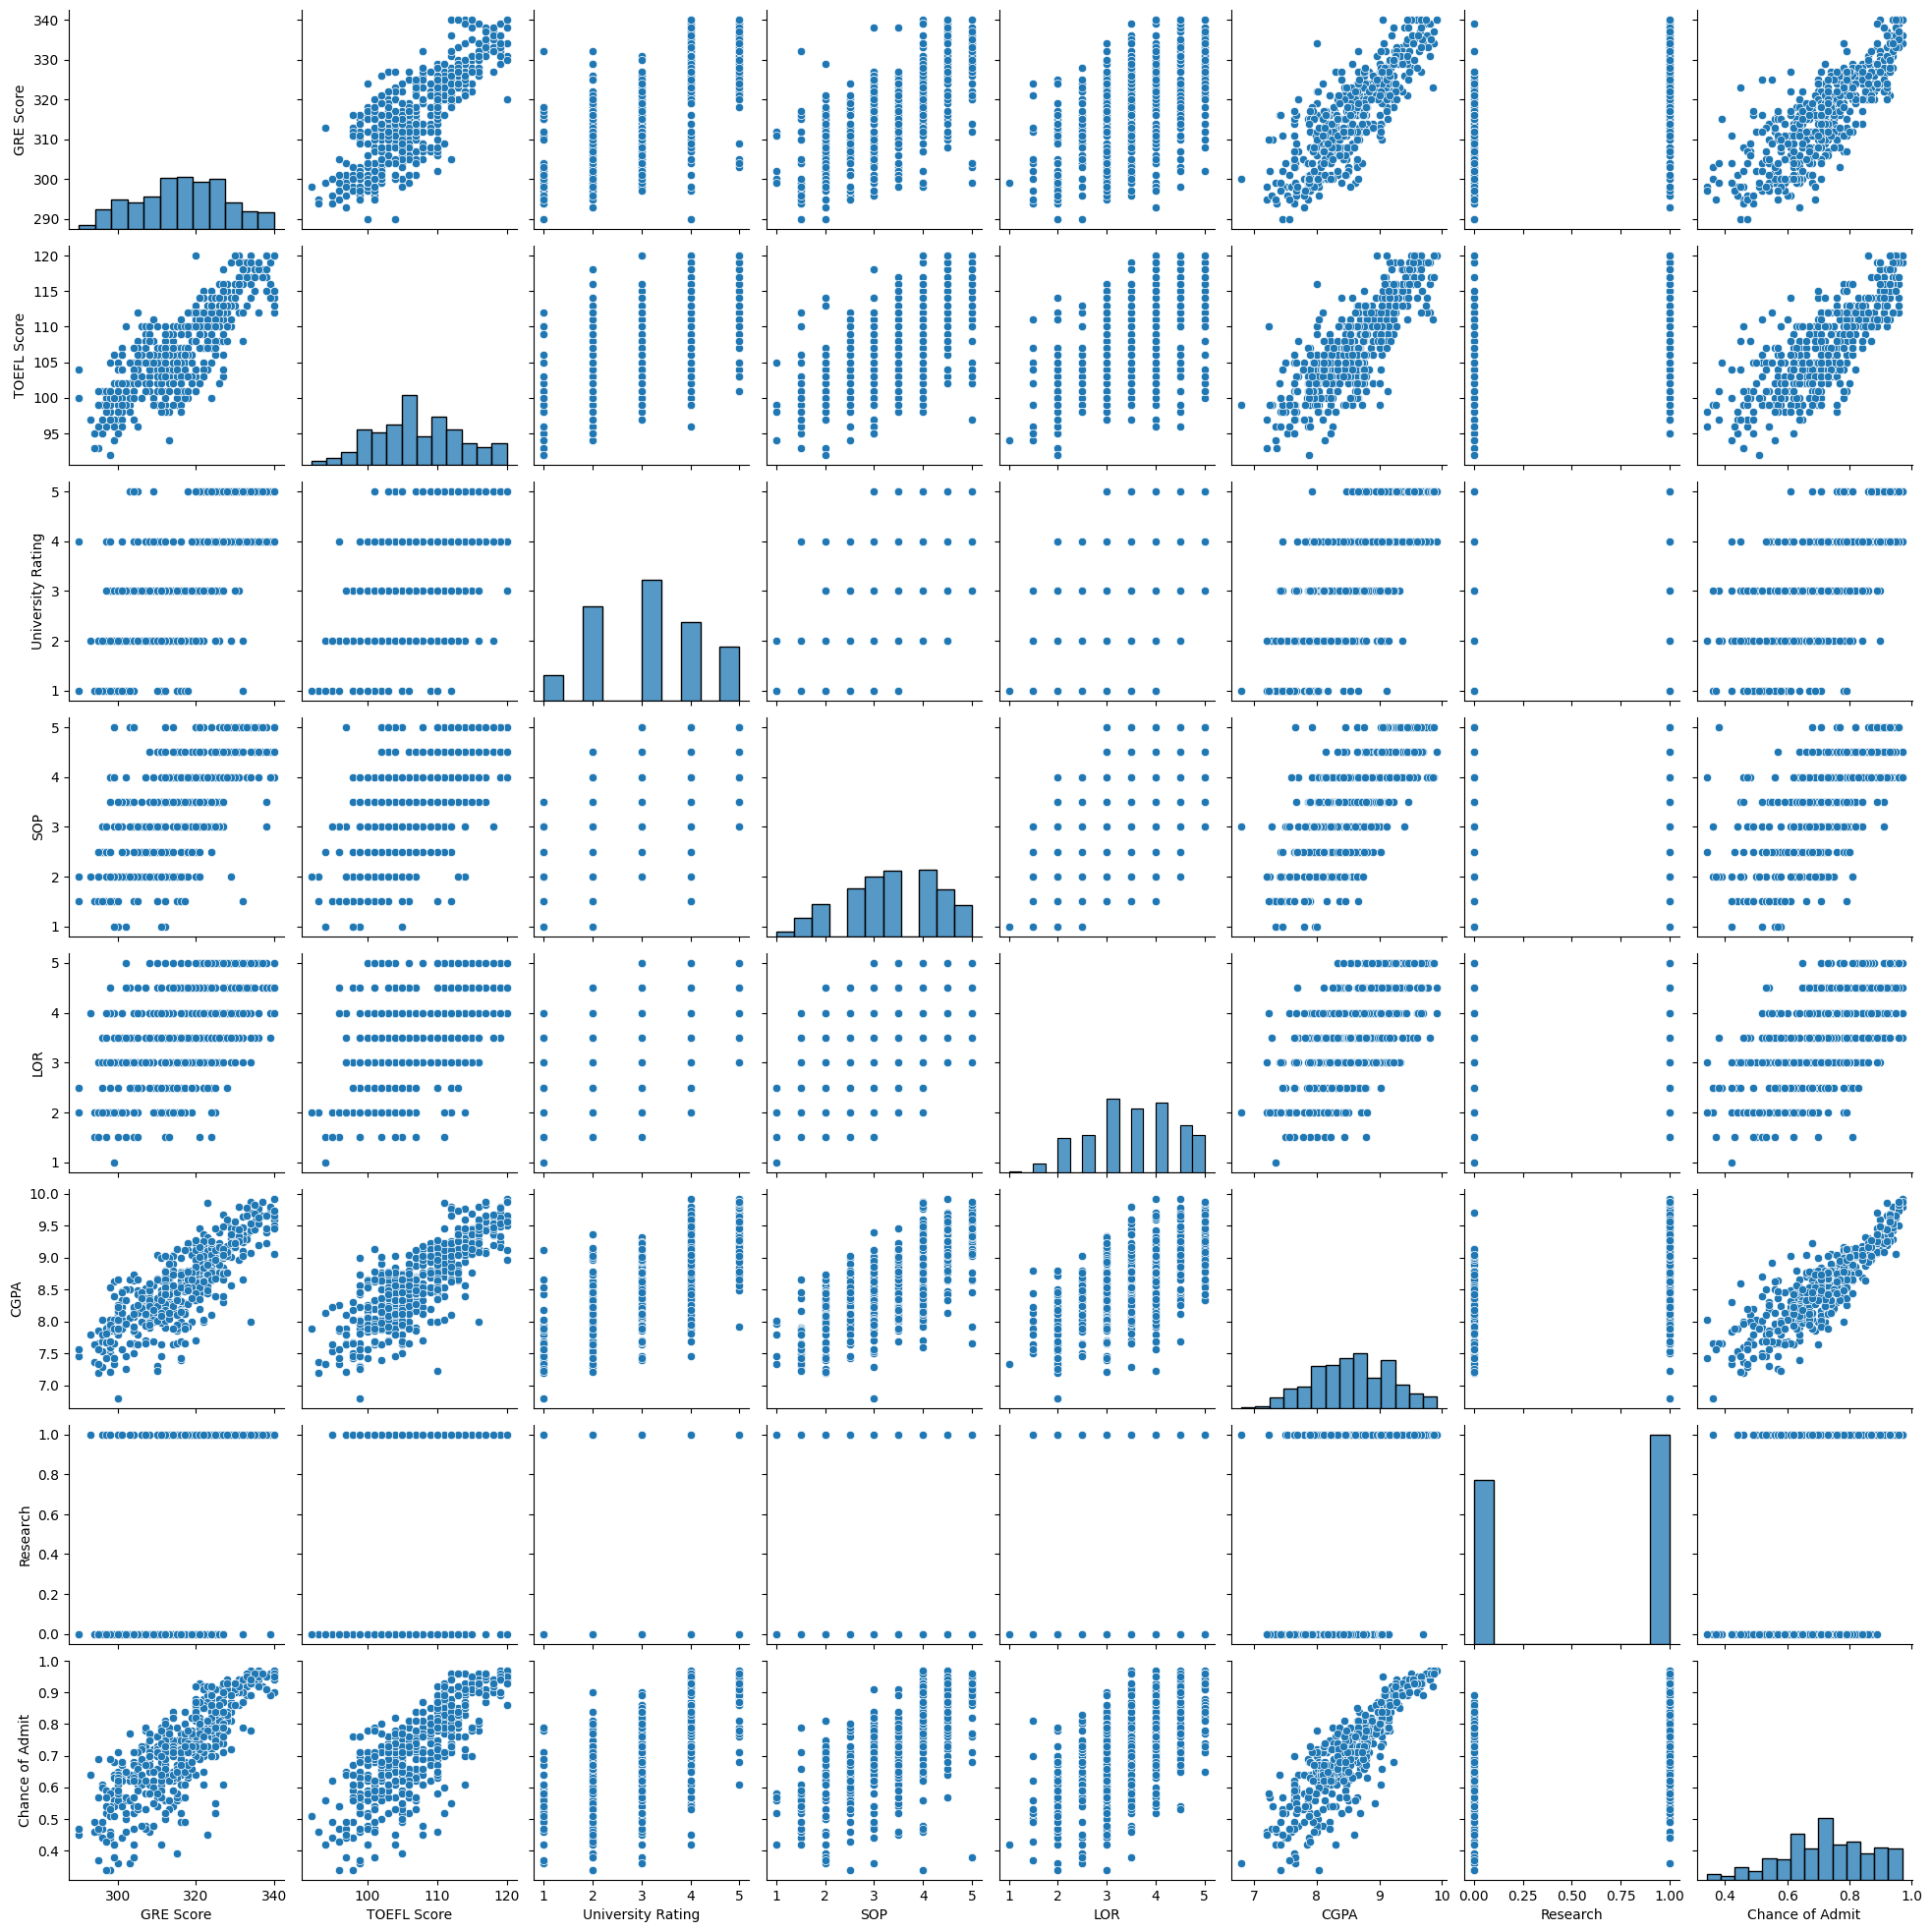

In [189]:
sns.pairplot(df)
plt.show()

From the pair plot we can see that the exams scores and chance of admit are highly correlated


<Axes: xlabel='Research', ylabel='Chance of Admit'>

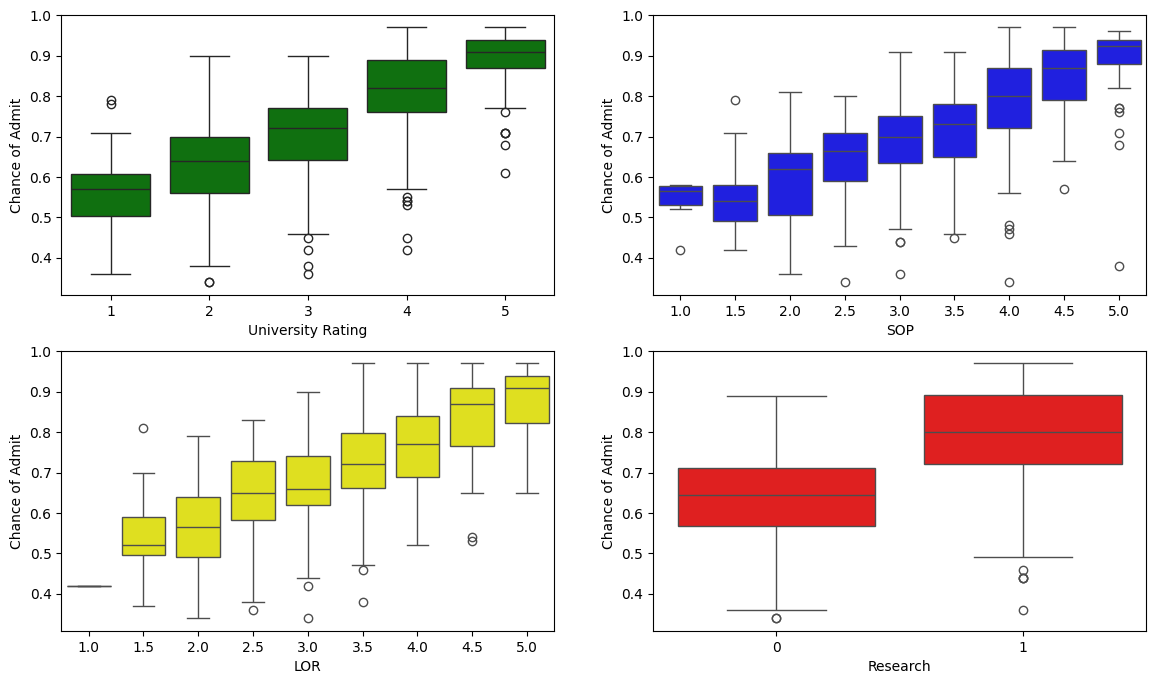

In [190]:
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
sns.boxplot(x=df['University Rating'],y=df['Chance of Admit'],ax=axis[0, 0],color="Green")
sns.boxplot(x=df['SOP'],y=df['Chance of Admit'],ax=axis[0, 1],color="Blue")
sns.boxplot(x=df['LOR'],y=df['Chance of Admit'],ax=axis[1, 0],color="Yellow")
sns.boxplot(x=df['Research'],y=df['Chance of Admit'],ax=axis[1,1],color="Red")



*   Students who have higher scores in University Rating, SOP, and LOR have a better chance of getting admitted to a top college. As these scores go up, the chances of admission also increase.
*   Students who have done research are more likely to get selected by top colleges compared to those who haven't done any research.



**Outliers Check**


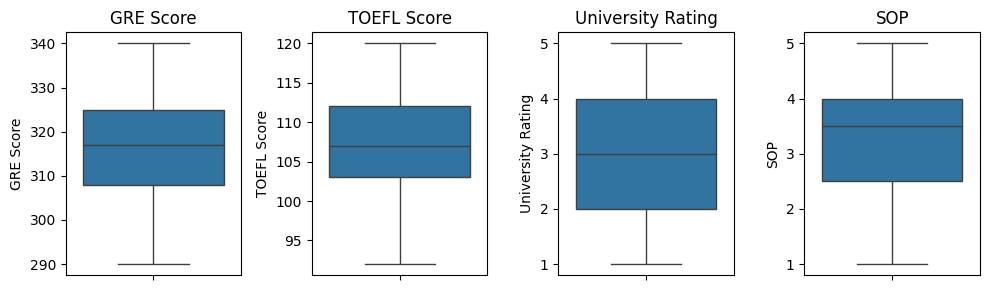

In [191]:
plt.figure(figsize=(10,3))

n_colms = df.select_dtypes(include=['float','int']).columns.tolist()
i=1
for col in n_colms:
    if i <= 4:
        ax=plt.subplot(1,4,i)
        sns.boxplot(df[col])
        plt.title(col)
        i+=1
    else:
        break

plt.tight_layout()
plt.show()

No Outliers are present in the given data

**Splitting Data**

In [192]:
c_colms = df.select_dtypes(include=['bool','category']).columns.tolist()

In [193]:
y = df['Chance of Admit']
x = df.drop('Chance of Admit',axis=1)

In [194]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [195]:
label_encoder ={}
for col in c_colms:
  label_encoder[col] = LabelEncoder()
  label_encoder[col].fit(x[col])

for col in c_colms:
  x_train[col] = label_encoder[col].transform(x_train[col])
  x_test[col] = label_encoder[col].transform(x_test[col])


In [196]:
x=pd.concat([x_train,x_test])
cols = x_train.columns

In [197]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train = pd.DataFrame(scaler.fit_transform(x_train),columns=cols)
x_test = pd.DataFrame(scaler.transform(x_test),columns=cols)


In [198]:
x_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.62,0.678571,0.50,0.625,0.714286,0.650641,1.0
1,0.52,0.678571,0.75,0.750,1.000000,0.557692,0.0
2,0.26,0.357143,0.50,0.625,0.428571,0.544872,0.0
3,0.48,0.535714,0.25,0.375,0.714286,0.471154,0.0
4,0.36,0.500000,0.50,0.625,0.285714,0.451923,1.0


In [199]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [200]:
model.coef_

array([0.12172192, 0.08388445, 0.01027519, 0.00725476, 0.06033294,
       0.3510845 , 0.02402679])

In [201]:
x_train.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='object')

**Weight of Coefficients**

In [202]:
m_coefficients = list(zip(x_train.columns, model.coef_))
m_coefficients = pd.DataFrame(m_coefficients, columns=['Feature', 'Weight'])

for feature,weight in zip(x_train.columns, model.coef_):
  print(f"{feature}: {np.round(weight,2)}")

GRE Score: 0.12
TOEFL Score: 0.08
University Rating: 0.01
SOP: 0.01
LOR: 0.06
CGPA: 0.35
Research: 0.02


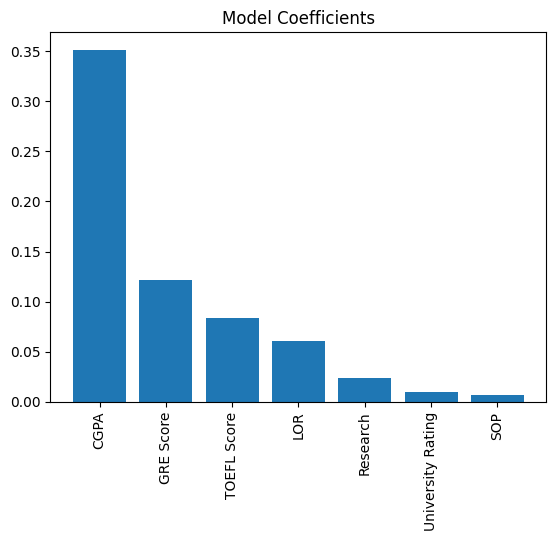

In [203]:
m_coefficients.sort_values(by='Weight', ascending=False,inplace=True)
plt.bar(x=m_coefficients.Feature, height=m_coefficients.Weight)
plt.title('Model Coefficients')
plt.xticks(rotation=90)
plt.show()

In [204]:
model.intercept_

np.float64(0.35558405022527073)

In [205]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

**Comparison of actual vs predicted**

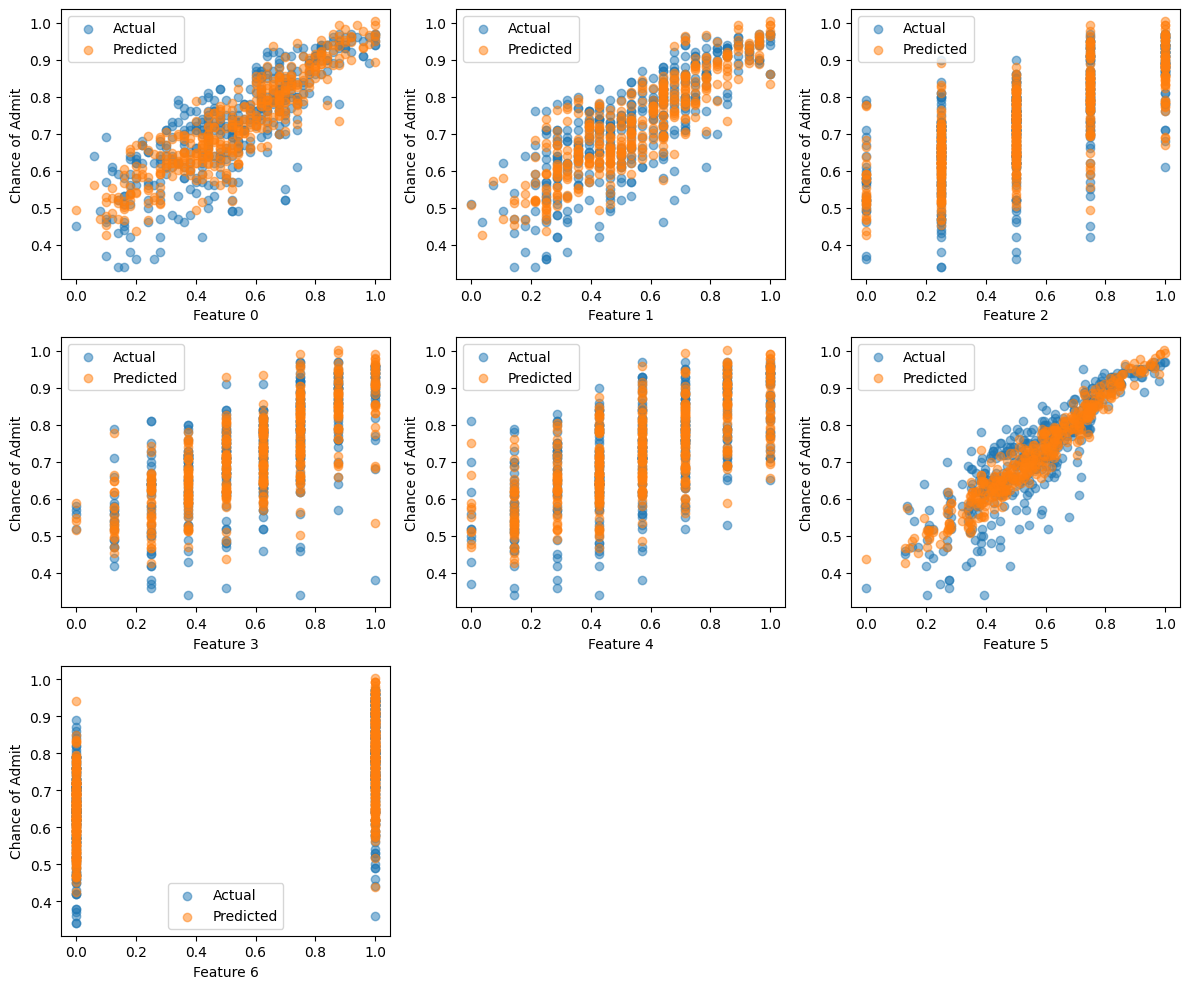

In [206]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

# Plotting each feature against y_train and y_pred_train
for i in range(x_train.shape[1]):
    ax = axes[i]
    ax.scatter(x_train.iloc[:, i], y_train, label='Actual', alpha=0.5)
    ax.scatter(x_train.iloc[:, i], y_pred_train, label='Predicted', alpha=0.5)
    ax.set_xlabel(f'Feature {i}')
    ax.set_ylabel('Chance of Admit')
    ax.legend()

# Removing empty subplots
for j in range(x_train.shape[1], len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [207]:
model.score(x_train,y_train)

0.8210671369321554

In [208]:
def r2_score(self, X, y):
    y_ = self.predict(X)
    ss_res = np.sum((y-y_)**2)
    ss_tot = np.sum((y- y.mean())**2)
    score = (1- ss_res/ss_tot)
    return score

In [209]:
r2_score(model,x_train,y_train)

np.float64(0.8210671369321554)

In [210]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [211]:
def model_evaluation(y_actual, y_pred, model):
  n = len(y_actual)
  if len(model.coef_.shape)==1:
    p = len(model.coef_)
  else:
    p = len(model.coef_[0])
  MAE = np.round(mean_absolute_error(y_true=y_actual, y_pred=y_pred),2)
  RMSE = np.round(np.sqrt(mean_squared_error(y_true=y_actual, y_pred=y_pred)),2)
  r2 = np.round(r2_score(y_true=y_actual, y_pred=y_pred),2)
  adj_r2 = np.round(1 - ((1-r2)*(n-1)/(n-p-1)),2)
  return print(f"Model Evaluation for {model}:\n MAE: {MAE}\n RMSE: {RMSE}\n r2: {r2}\n adj_r2: {adj_r2}")

In [212]:
model_evaluation(y_train,y_pred_train,model)

Model Evaluation for LinearRegression():
 MAE: 0.04
 RMSE: 0.06
 r2: 0.82
 adj_r2: 0.82


In [213]:
model_evaluation(y_test,y_pred_test,model)

Model Evaluation for LinearRegression():
 MAE: 0.04
 RMSE: 0.06
 r2: 0.82
 adj_r2: 0.81


**Assumptions of Linear Regression**


***Multicollinearity***

In [214]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [215]:
x_train_copy = x_train.copy()

In [216]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train_copy.values, i) for i in range(x_train_copy.shape[1])]
vif['Features'] = x_train_copy.columns
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,VIF,Features
5,39.76,CGPA
0,31.20,GRE Score
1,26.76,TOEFL Score
3,18.57,SOP
4,11.01,LOR
2,10.95,University Rating
6,3.36,Research


In [217]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train_copy.values, i) for i in range(x_train_copy.shape[1])]
vif['Features'] = x_train_copy.columns
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,VIF,Features
5,39.76,CGPA
0,31.20,GRE Score
1,26.76,TOEFL Score
3,18.57,SOP
4,11.01,LOR
2,10.95,University Rating
6,3.36,Research


In [218]:
x_train_copy.drop('GRE Score',axis=1,inplace=True)

In [219]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train_copy.values, i) for i in range(x_train_copy.shape[1])]
vif['Features'] = x_train_copy.columns
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,VIF,Features
4,31.63,CGPA
0,21.46,TOEFL Score
2,18.56,SOP
3,10.98,LOR
1,10.91,University Rating
5,3.03,Research


In [220]:
x_train_copy.drop('SOP',axis=1,inplace=True)

In [221]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train_copy.values, i) for i in range(x_train_copy.shape[1])]
vif['Features'] = x_train_copy.columns
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,VIF,Features
3,29.09,CGPA
0,21.10,TOEFL Score
2,9.86,LOR
1,9.80,University Rating
4,3.03,Research


In [222]:
x_train_copy.drop('TOEFL Score',axis=1,inplace=True)

In [223]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train_copy.values, i) for i in range(x_train_copy.shape[1])]
vif['Features'] = x_train_copy.columns
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,VIF,Features
2,14.49,CGPA
1,9.86,LOR
0,9.49,University Rating
3,3.00,Research


In [224]:
model_lr = LinearRegression()
model_lr.fit(x_train_copy,y_train)
model_evaluation(y_train,model_lr.predict(x_train_copy),model_lr)

Model Evaluation for LinearRegression():
 MAE: 0.05
 RMSE: 0.06
 r2: 0.8
 adj_r2: 0.8




*   While the error measurements (MAE and RMSE) have improved, both R2 and adjusted R2 have decreased compared to the model that used all features.
*   We can see that most features except Research show high collinearity. This matches what we saw in the correlation heatmap, which showed strong positive relationships between CGPA, GRE scores, and TOEFL scores.





**Mean of Residuals**

In [225]:
residuals = y_test - y_pred_test
residuals.mean()

np.float64(-0.00545362371766125)

<Axes: xlabel='Chance of Admit', ylabel='Count'>

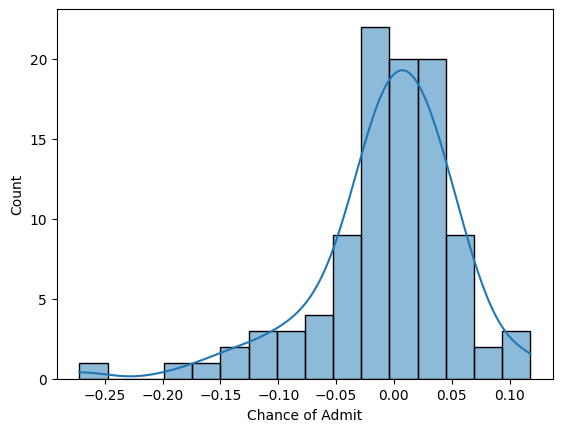

In [226]:
sns.histplot(residuals,kde=True)

In [227]:
res = stats.shapiro(residuals)
res.statistic

np.float64(0.9178703251544263)

**Linearity of Variables**


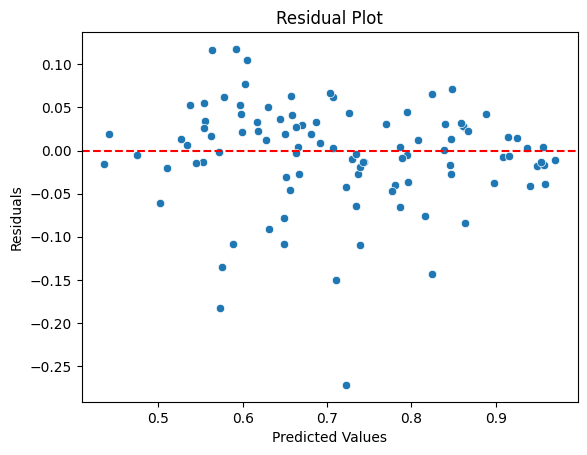

In [228]:
sns.scatterplot(x = y_pred_test.reshape((-1,)), y=residuals)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.show();

**Homoscedasticity**

Text(0.5, 1.0, 'Predicted values vs Residuals')

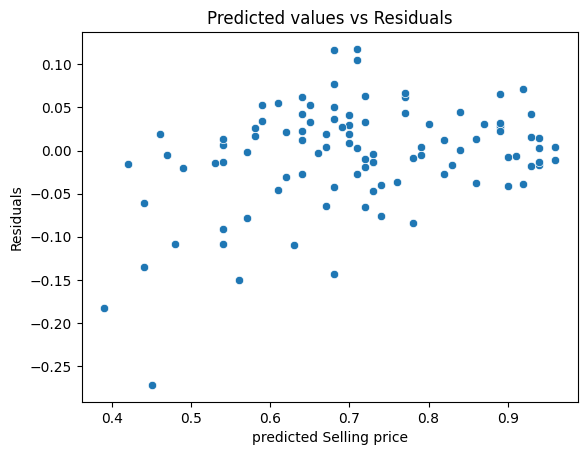

In [229]:
sns.scatterplot(x=y_test,y=residuals)
plt.xlabel("predicted Selling price")
plt.ylabel("Residuals")
plt.title("Predicted values vs Residuals")

**Normality of residuals**

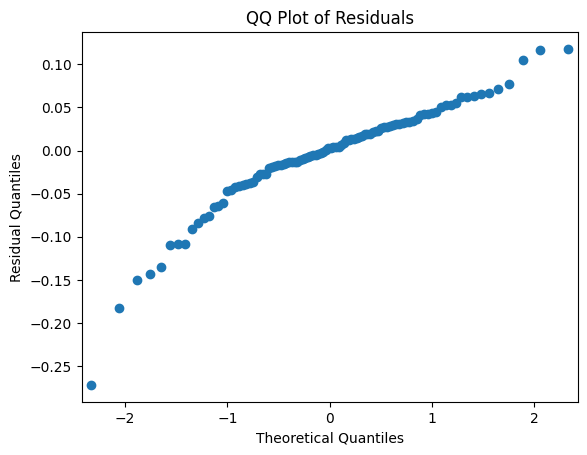

In [230]:
sm.qqplot(residuals)
plt.title('QQ Plot of Residuals')
plt.ylabel('Residual Quantiles')
plt.show()

**Regularization of Linear Model**

In [231]:
model_ridge = Ridge(alpha=1)
model_lasso = Lasso(alpha=0.01)

In [232]:
model_ridge.fit(x_train,y_train)
model_lasso.fit(x_train,y_train)

Lasso(alpha=0.01)

In [233]:
Y_pred_ridge = model_ridge.predict(x_train)
Y_pred_lasso = model_lasso.predict(x_train)

In [234]:
model_evaluation(y_train,Y_pred_ridge,model_ridge)

Model Evaluation for Ridge(alpha=1):
 MAE: 0.04
 RMSE: 0.06
 r2: 0.82
 adj_r2: 0.82


In [235]:
model_evaluation(y_train,Y_pred_lasso,model_lasso)

Model Evaluation for Lasso(alpha=0.01):
 MAE: 0.06
 RMSE: 0.08
 r2: 0.67
 adj_r2: 0.66


In [236]:
y_pred_lasso = model_lasso.predict(x_test)
model_evaluation(y_test,y_pred_lasso,model_lasso)

Model Evaluation for Lasso(alpha=0.01):
 MAE: 0.06
 RMSE: 0.08
 r2: 0.69
 adj_r2: 0.67


Based on the evaluation scores we can see that Linear Regression and Ridge Regression performed equally well, while Lasso Regression didn't perform as effectively as the other two models.

**Comparison of Model Performance**

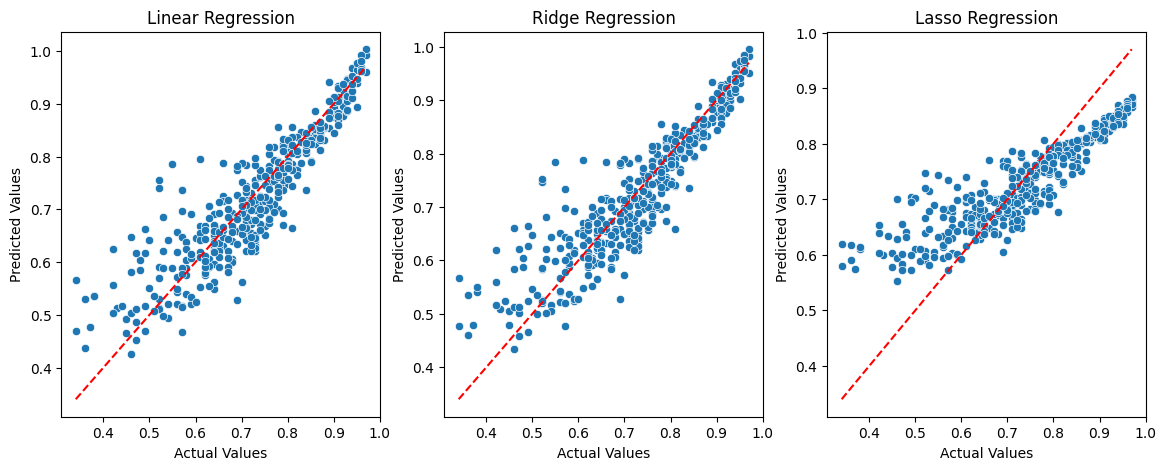

In [237]:
actual_values = y_train.values
predicted_values = [y_pred_train, Y_pred_ridge, Y_pred_lasso]

model = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']

plt.figure(figsize=(14, 5))
for i in range(len(predicted_values)):
    ax = plt.subplot(1, 3, i+1)
    sns.scatterplot(x=actual_values, y=predicted_values[i], ax=ax)
    plt.plot([min(actual_values),max(actual_values)], [min(actual_values),max(actual_values)], color='red', linestyle='--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(model[i])
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')

The graphs show Linear Regression and Ridge Regression performing with nearly identical accuracy.

**Insights**
- Higher university ranking, strong research background, and well-rated SOP/LOR improve admission chances.
- Exam scores (GRE, TOEFL) show a strong positive correlation with admission probability.
- Admission chances follow a left-skewed distribution, meaning fewer students have very high probabilities.
- CGPA is the most influential factor, while SOP and university rating contribute less, based on regression model weights.
- Linear Regression and Ridge Regression models explain around 82% of the variance in admission chances.
- High collinearity among predictor variables limits further improvement in the model.
- Predictor variables meet Linear Regression assumptions, with residuals centered around zero.
- Residuals exhibit normal distribution, confirming model stability.
- Homoscedasticity is present, meaning the spread of residuals is consistent across predicted values.


**Recommendations**
-  Adding more independent features, such as extracurricular activities, could refine the model.
- Creating a composite score for GRE and TOEFL can account for their combined effect on admissions.
- Introducing a weighted average metric incorporating CGPA and university ranking can improve academic performance representation.
- Including work experience or prior projects may enhance prediction accuracy for admission chances.
- Adding features related to internships or field-specific research projects could provide deeper insights.
- Considering application submission timing as a feature may reveal seasonal trends in admission decisions.
- Incorporating financial aid request status could help assess institutional decision-making influences.
